# EzaSmart Hydroponics RAG Chatbot

This notebook trains a hybrid RAG (Retrieval-Augmented Generation) chatbot that answers hydroponics questions. When you ask something, it first searches the knowledge base for similar questions. If it finds a good match (similarity ≥ 0.4), it returns that answer. Otherwise, it generates a new answer using a fine-tuned T5 model.

The knowledge base has ~1,100 Q&A pairs from StackExchange (expert answers) and Wikipedia (encyclopedic knowledge).

## 1. Setup and Dependencies

Detects whether we're running locally or on Colab, then installs the required packages: `transformers` (for T5 model), `torch` (neural network backend), `scikit-learn` (TF-IDF and similarity), `pandas`/`numpy` (data handling), and `matplotlib`/`seaborn` (visualization).

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Running locally")

Running in Google Colab


In [2]:
import subprocess
import sys

def install_package(package: str) -> None:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package],
                            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print(f"Installed: {package}")
    except subprocess.CalledProcessError:
        print(f"Failed: {package}")

for pkg in ["transformers>=4.25.0", "torch", "scikit-learn", "pandas", "matplotlib", "seaborn"]:
    install_package(pkg)

print("\nPackages ready!")

Installed: transformers>=4.25.0
Installed: torch
Installed: scikit-learn
Installed: pandas
Installed: matplotlib
Installed: seaborn

Packages ready!


In [3]:
import re
import json
import warnings
import os
from pathlib import Path
from typing import List, Tuple

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from transformers import T5Config, T5Tokenizer, T5ForConditionalGeneration

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    BASE_DIR = Path("/content")
    PROJECT_ROOT = Path("/content")
    print("Colab environment detected")
else:
    BASE_DIR = Path(os.getcwd())
    if 'Models' not in str(BASE_DIR):
        BASE_DIR = BASE_DIR / 'Models' / 'chatbot'
    elif BASE_DIR.name != 'chatbot':
        BASE_DIR = BASE_DIR / 'chatbot'
    PROJECT_ROOT = BASE_DIR.parent.parent

if IN_COLAB:
    HYDRO_QA_PATH = BASE_DIR / "hydro_qa_data.json"
    WIKIPEDIA_PATH = BASE_DIR / "wikipedia_hydro_knowledge.json"
else:
    HYDRO_QA_PATH = PROJECT_ROOT / "Models" / "hydro_qa_data.json"
    WIKIPEDIA_PATH = PROJECT_ROOT / "Models" / "wikipedia_hydro_knowledge.json"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"Working directory: {BASE_DIR}")
print(f"Project root: {PROJECT_ROOT}")

Colab environment detected
Device: cpu
Working directory: /content
Project root: /content


## 2. Load the T5 Model

Loads the `Afsa20/Farmsmart_Growmate` model from HuggingFace - this is a T5 model fine-tuned on hydroponics data. It has about 60M parameters and runs in FP16 on GPU or FP32 on CPU. This model only gets used when the retrieval system can't find a good match (similarity < 0.4).

In [4]:
MODEL_NAME = "Afsa20/Farmsmart_Growmate"

print(f"Loading {MODEL_NAME}...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
config = T5Config.from_pretrained(MODEL_NAME)
config.tie_word_embeddings = False

model = T5ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    config=config,
    torch_dtype=torch.float16 if device.type == 'cuda' else torch.float32,
    device_map="auto" if device.type == 'cuda' else None
)

if device.type == 'cpu':
    model = model.to(device)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Model loaded: {model.num_parameters():,} parameters")
print(f"Tokenizer vocab: {len(tokenizer):,} tokens")

Loading Afsa20/Farmsmart_Growmate...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

Model loaded: 296,926,464 parameters
Tokenizer vocab: 32,100 tokens


## 3. Load StackExchange Data

Loads Q&A pairs scraped from StackExchange Gardening & Landscaping. These are expert-verified answers to practical hydroponics questions. The data gets cleaned (whitespace/newlines removed) and filtered (minimum 10 characters for questions and answers). Usually around ~115 pairs.

In [6]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[\r\n]+', ' ', text)
    return text

def load_hydro_qa(path: Path) -> Tuple[List[str], List[str]]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    instructions = []
    responses = []
    min_len = 10

    for item in data:
        inst = clean_text(item.get("instruction", ""))
        resp = clean_text(item.get("response", ""))
        if len(inst) > min_len and len(resp) > min_len:
            instructions.append(inst)
            responses.append(resp)

    return instructions, responses

hydro_instructions, hydro_responses = load_hydro_qa(HYDRO_QA_PATH)
print(f"Loaded StackExchange: {len(hydro_instructions):,} Q&A pairs")
print(f"Sample question: {hydro_instructions[0][:80]}...")

Loaded StackExchange: 115 Q&A pairs
Sample question: How often should I harvest herbs? I have a few herbs growing hydroponically (bas...


## 4. Load Wikipedia Data

Loads Q&A pairs extracted from Wikipedia hydroponics articles. These cover definitions, techniques, systems, and nutrient science. Same cleaning process as StackExchange data. Usually around ~1,000+ pairs.

In [7]:
def load_wikipedia_qa(path: Path) -> Tuple[List[str], List[str]]:
    if not path.exists():
        print(f"Wikipedia data not found: {path}")
        return [], []

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    instructions = []
    responses = []
    min_len = 10

    for item in data:
        inst = clean_text(item.get("instruction", ""))
        resp = clean_text(item.get("response", ""))
        if len(inst) > min_len and len(resp) > min_len:
            instructions.append(inst)
            responses.append(resp)

    return instructions, responses

wiki_instructions, wiki_responses = load_wikipedia_qa(WIKIPEDIA_PATH)
print(f"Loaded Wikipedia: {len(wiki_instructions):,} Q&A pairs")
print(f"Sample question: {wiki_instructions[0][:80]}...")

Loaded Wikipedia: 1,015 Q&A pairs
Sample question: What is Hydroponics?...


## 5. Combine Datasets

Merges StackExchange and Wikipedia data into three parallel lists: questions, answers, and sources. Each Q&A pair gets tagged with its source so we can track where answers come from.

In [8]:
all_questions = []
all_answers = []
all_sources = []

for q, a in zip(hydro_instructions, hydro_responses):
    all_questions.append(q)
    all_answers.append(a)
    all_sources.append("StackExchange")

for q, a in zip(wiki_instructions, wiki_responses):
    all_questions.append(q)
    all_answers.append(a)
    all_sources.append("Wikipedia")

print(f"Total Q&A pairs: {len(all_questions):,}")
print(f"  - StackExchange: {len(hydro_instructions):,}")
print(f"  - Wikipedia: {len(wiki_instructions):,}")

Total Q&A pairs: 1,130
  - StackExchange: 115
  - Wikipedia: 1,015


## 6. Clean and Deduplicate

Removes duplicate Q&A pairs in three steps:
1. Exact duplicates (same question AND answer)
2. Case-insensitive duplicates (lowercase comparison)
3. Low-quality pairs (questions <15 chars or answers <20 chars)

In [9]:
df = pd.DataFrame({
    'question': all_questions,
    'answer': all_answers,
    'source': all_sources
})

print("BEFORE CLEANING")
print(f"Total pairs: {len(df):,}")

cleaned_df = df.copy()

print("\nREMOVING DUPLICATES")
exact_dups = cleaned_df.duplicated(subset=['question', 'answer']).sum()
print(f"  Exact duplicate Q&A pairs: {exact_dups}")
cleaned_df = cleaned_df.drop_duplicates(subset=['question', 'answer'], keep='first')

cleaned_df['question_normalized'] = cleaned_df['question'].str.lower().str.strip()
cleaned_df['answer_normalized'] = cleaned_df['answer'].str.lower().str.strip()

same_qa = cleaned_df.duplicated(subset=['question_normalized', 'answer_normalized'], keep='first').sum()
print(f"  Same questions with same answers (case-insensitive): {same_qa}")
cleaned_df = cleaned_df.drop_duplicates(subset=['question_normalized', 'answer_normalized'], keep='first')

cleaned_df = cleaned_df.drop(columns=['question_normalized', 'answer_normalized'])

print("\nREMOVING LOW-QUALITY PAIRS")
min_question_len = 15
min_answer_len = 20
before_quality = len(cleaned_df)

cleaned_df['question_len'] = cleaned_df['question'].str.len()
cleaned_df['answer_len'] = cleaned_df['answer'].str.len()

cleaned_df = cleaned_df[
    (cleaned_df['question_len'] >= min_question_len) &
    (cleaned_df['answer_len'] >= min_answer_len)
]

removed_quality = before_quality - len(cleaned_df)
print(f"  Removed {removed_quality} pairs with short questions (<{min_question_len} chars) or answers (<{min_answer_len} chars)")

print("\nAFTER CLEANING")
print(f"Total pairs: {len(cleaned_df):,}")
print(f"Removed: {len(df) - len(cleaned_df):,} pairs ({((len(df) - len(cleaned_df))/len(df)*100):.1f}%)")
print("\nCleaned data by source:")
for src, count in cleaned_df.groupby('source').size().items():
    pct = (count / len(cleaned_df)) * 100
    print(f"  {src:15s}: {count:5,} pairs ({pct:5.1f}%)")

all_questions = cleaned_df['question'].tolist()
all_answers = cleaned_df['answer'].tolist()
all_sources = cleaned_df['source'].tolist()

print(f"\nFinal dataset ready: {len(all_questions):,} Q&A pairs")

BEFORE CLEANING
Total pairs: 1,130

REMOVING DUPLICATES
  Exact duplicate Q&A pairs: 0
  Same questions with same answers (case-insensitive): 0

REMOVING LOW-QUALITY PAIRS
  Removed 26 pairs with short questions (<15 chars) or answers (<20 chars)

AFTER CLEANING
Total pairs: 1,104
Removed: 26 pairs (2.3%)

Cleaned data by source:
  StackExchange  :   115 pairs ( 10.4%)
  Wikipedia      :   989 pairs ( 89.6%)

Final dataset ready: 1,104 Q&A pairs


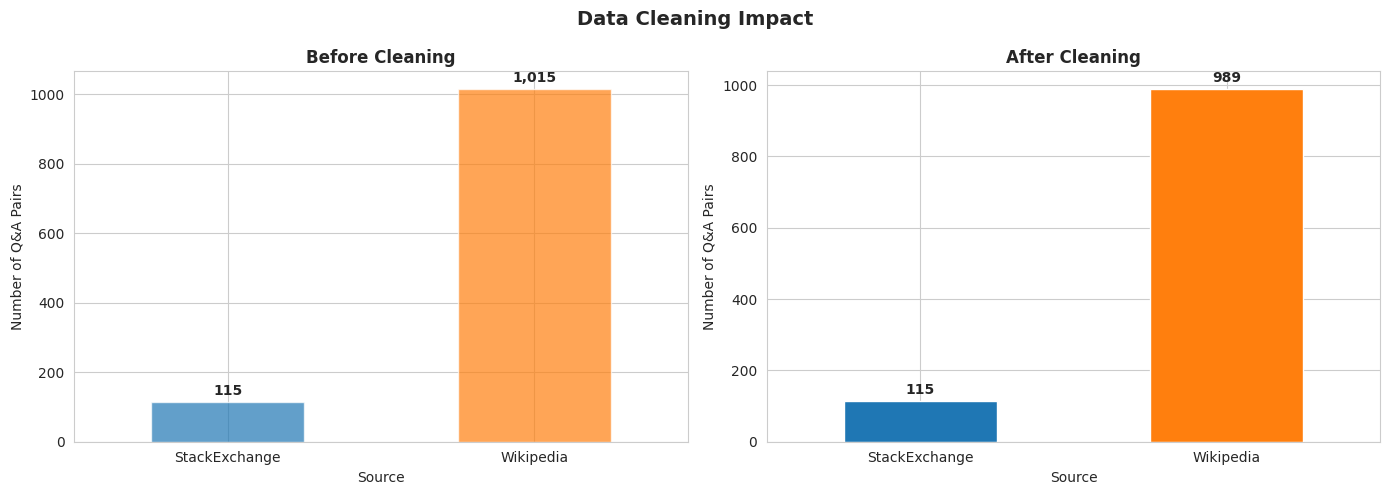


CLEANING SUMMARY
StackExchange  :   115 ->   115 (   0 removed,   0.0%)
Wikipedia      : 1,015 ->   989 (  26 removed,   2.6%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Data Cleaning Impact", fontsize=14, fontweight='bold')

colors = {'StackExchange': '#1f77b4', 'Wikipedia': '#ff7f0e', 'Batavia': '#2ca02c'}

ax1 = axes[0]
before_counts = df.groupby('source').size()
before_counts.plot(kind='bar', ax=ax1, color=[colors[x] for x in before_counts.index], alpha=0.7)
ax1.set_title('Before Cleaning', fontsize=12, fontweight='bold')
ax1.set_xlabel('Source')
ax1.set_ylabel('Number of Q&A Pairs')
ax1.tick_params(axis='x', rotation=0)
for i, v in enumerate(before_counts.values):
    ax1.text(i, v + max(before_counts.values)*0.02, f'{v:,}', ha='center', fontweight='bold')

ax2 = axes[1]
after_counts = cleaned_df.groupby('source').size()
after_counts.plot(kind='bar', ax=ax2, color=[colors[x] for x in after_counts.index])
ax2.set_title('After Cleaning', fontsize=12, fontweight='bold')
ax2.set_xlabel('Source')
ax2.set_ylabel('Number of Q&A Pairs')
ax2.tick_params(axis='x', rotation=0)
for i, v in enumerate(after_counts.values):
    ax2.text(i, v + max(after_counts.values)*0.02, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCLEANING SUMMARY")
for src in df['source'].unique():
    before = len(df[df['source'] == src])
    after = len(cleaned_df[cleaned_df['source'] == src])
    removed = before - after
    pct = (removed / before * 100) if before > 0 else 0
    print(f"{src:15s}: {before:5,} -> {after:5,} ({removed:4,} removed, {pct:5.1f}%)")

## 7. Build RAG System

Builds a TF-IDF index over all questions (5,000 features, unigrams + bigrams). When you ask a question:
1. It converts your question to a TF-IDF vector
2. Computes cosine similarity with all knowledge base questions
3. If best match ≥ 0.4 similarity → return that answer (retrieval mode)
4. If best match < 0.4 → generate new answer with T5 (generative mode)

Retrieval mode is fast and accurate. Generative mode handles novel questions but is slower.

In [11]:
print(f"Building TF-IDF index over {len(all_questions):,} Q&A pairs...")

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(all_questions)

print(f"Index built: {tfidf_matrix.shape[0]:,} documents, {tfidf_matrix.shape[1]:,} features")
print(f"  - StackExchange: {all_sources.count('StackExchange'):,}")
print(f"  - Wikipedia: {all_sources.count('Wikipedia'):,}")

Building TF-IDF index over 1,104 Q&A pairs...
Index built: 1,104 documents, 5,000 features
  - StackExchange: 115
  - Wikipedia: 989


In [12]:
def retrieve_answers(query: str, top_k: int = 3):
    query_vec = tfidf_vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            'score': float(similarities[idx]),
            'question': all_questions[idx],
            'answer': all_answers[idx],
            'source': all_sources[idx]
        })
    return results

def generate_answer(question: str, max_length: int = 150) -> str:
    input_text = f"Answer this hydroponic farming question: {question}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            min_length=15,
            num_beams=4,
            early_stopping=True,
            repetition_penalty=2.5,
            no_repeat_ngram_size=3,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

def answer_question(question: str, threshold: float = 0.4, use_print: bool = True):
    results = retrieve_answers(question, top_k=3)

    if results and results[0]['score'] >= threshold:
        best = results[0]
        if use_print:
            print(f"[RETRIEVAL MODE] Similarity score: {best['score']:.3f}")
            print(f"Source: {best['source']}\n")
            print(f"Matched question:\n{best['question']}\n")
            print(f"Answer:\n{best['answer']}")
        return best['answer'], 'retrieval', best['score']
    else:
        answer = generate_answer(question)
        if use_print:
            print(f"[GENERATIVE MODE] Using base model (fallback)\n")
            print(f"Answer:\n{answer}")
        return answer, 'generative', None

print("\nRAG system ready!")
print(f"Knowledge base: {len(all_questions):,} Q&A pairs")
print(f"Retrieval threshold: 0.4 (similarity score)")
print(f"Strategy: Retrieval-first, generative fallback")


RAG system ready!
Knowledge base: 1,104 Q&A pairs
Retrieval threshold: 0.4 (similarity score)
Strategy: Retrieval-first, generative fallback


## 8. Test the System

Tests the chatbot with 4 sample questions covering different topics (pH levels, algae prevention, tip burn, solution changes). For each question, it shows whether it used retrieval or generative mode and displays the answer.

In [13]:
test_questions = [
    "What is the ideal pH for hydroponic lettuce?",
    "How do I prevent algae in my system?",
    "What causes tip burn in lettuce?",
    "How often should I change nutrient solution?"
]

print("Testing RAG system with sample questions:\n")

for i, question in enumerate(test_questions, 1):
    print(f"\nTest {i}: {question}")
    answer, mode, score = answer_question(question, threshold=0.4)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Testing RAG system with sample questions:


Test 1: What is the ideal pH for hydroponic lettuce?
[GENERATIVE MODE] Using base model (fallback)

Answer:
pH 5.8–6.2 e.t alkaline is ideal for leafy greens but too high can result in overly acidic leaves and poor airflow to the plant system; adjust slightly more before adding nutrients back into your growing medium (such as calcium or magnesium).

Test 2: How do I prevent algae in my system?
[GENERATIVE MODE] Using base model (fallback)

Answer:
Use pH 5.8–6.2; keep nutrient solution moderate and avoid direct sunlight.

Test 3: What causes tip burn in lettuce?
[RETRIEVAL MODE] Similarity score: 0.426
Source: StackExchange

Matched question:
Cilantro tip burn What could be the problem causing cilantro to have this kind of tip burn / necrotic center? It's grown in a hydroponic shallow raft bed under LED grow light. This always happens after some period of time. Parameters are: pH - 5,2 EC - 1650 NO3 - 90ppm K - 102ppm Ca - 115ppm

Answer:
Thi

## 9. Save Everything

Saves the trained system to disk so you can load it later without reprocessing:
- `tfidf_vectorizer.pkl` - the fitted TF-IDF model
- `tfidf_matrix.pkl` - the sparse matrix of all questions
- `knowledge_base.pkl` - all questions, answers, and source labels
- `metadata.json` - stats about the system (model name, number of pairs, etc.)

In [14]:
import pickle
from datetime import datetime

RAG_OUTPUT_DIR = BASE_DIR / "rag_system"
RAG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Saving RAG system to: {RAG_OUTPUT_DIR}")

print("\n1. Saving TF-IDF vectorizer...")
with open(RAG_OUTPUT_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)
print("   Saved: tfidf_vectorizer.pkl")

print("\n2. Saving TF-IDF matrix...")
with open(RAG_OUTPUT_DIR / "tfidf_matrix.pkl", "wb") as f:
    pickle.dump(tfidf_matrix, f)
print("   Saved: tfidf_matrix.pkl")

print("\n3. Saving knowledge base...")
knowledge_base = {
    'questions': all_questions,
    'answers': all_answers,
    'sources': all_sources
}
with open(RAG_OUTPUT_DIR / "knowledge_base.pkl", "wb") as f:
    pickle.dump(knowledge_base, f)
print("   Saved: knowledge_base.pkl")

print("\n4. Saving metadata...")
metadata = {
    'model_name': MODEL_NAME,
    'total_pairs': len(all_questions),
    'stackexchange_pairs': all_sources.count('StackExchange'),
    'wikipedia_pairs': all_sources.count('Wikipedia'),
    'retrieval_threshold': 0.4,
    'tfidf_features': tfidf_matrix.shape[1],
    'created_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'python_version': sys.version.split()[0]
}
with open(RAG_OUTPUT_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print("   Saved: metadata.json")

print(f"\nRAG system saved successfully!")
print(f"Location: {RAG_OUTPUT_DIR}")
print(f"\nSaved files:")
print(f"  - tfidf_vectorizer.pkl ({(RAG_OUTPUT_DIR / 'tfidf_vectorizer.pkl').stat().st_size / 1024:.1f} KB)")
print(f"  - tfidf_matrix.pkl ({(RAG_OUTPUT_DIR / 'tfidf_matrix.pkl').stat().st_size / 1024:.1f} KB)")
print(f"  - knowledge_base.pkl ({(RAG_OUTPUT_DIR / 'knowledge_base.pkl').stat().st_size / 1024:.1f} KB)")
print(f"  - metadata.json ({(RAG_OUTPUT_DIR / 'metadata.json').stat().st_size / 1024:.1f} KB)")

Saving RAG system to: /content/rag_system

1. Saving TF-IDF vectorizer...
   Saved: tfidf_vectorizer.pkl

2. Saving TF-IDF matrix...
   Saved: tfidf_matrix.pkl

3. Saving knowledge base...
   Saved: knowledge_base.pkl

4. Saving metadata...
   Saved: metadata.json

RAG system saved successfully!
Location: /content/rag_system

Saved files:
  - tfidf_vectorizer.pkl (201.2 KB)
  - tfidf_matrix.pkl (145.2 KB)
  - knowledge_base.pkl (571.1 KB)
  - metadata.json (0.2 KB)
